In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
from sklearn.cluster import KMeans

%matplotlib inline

## Loading the training data

Two training sets: one with repeated gestures (same gesture done multiple times in one recording) and one with single gestures.

In [2]:
# paths
repeated_dir = 'data/Repeated_gesture'
single_dir = 'data/Single_gesture'

# figure out which files belong to which gesture
# the naming is kinda inconsistent lol
gesture_prefixes = {
    'wave': 'wave',
    'inf': 'inf',       # infinity
    'eight': 'eight',
    'circle': 'circle',
    'beat3': 'beat3',
    'beat4': 'beat4'
}

def load_imu(fpath):
    raw = np.loadtxt(fpath)
    # columns: ts, Wx, Wy, Wz, Ax, Ay, Az
    # drop timestamp, keep 6D IMU
    return raw[:, 1:]

# load repeated gesture files
repeated_data = {}
for gname, prefix in gesture_prefixes.items():
    files = sorted(glob.glob(os.path.join(repeated_dir, prefix + '*.txt')))
    repeated_data[gname] = [load_imu(f) for f in files]
    print(f"{gname}: {len(files)} files, shapes: {[d.shape for d in repeated_data[gname]]}")

print()

# load single gesture files  
single_data = {}
for gname, prefix in gesture_prefixes.items():
    files = sorted(glob.glob(os.path.join(single_dir, prefix + '*.txt')))
    single_data[gname] = [load_imu(f) for f in files]
    print(f"{gname}: {len(files)} files, shapes: {[d.shape for d in single_data[gname]]}")

wave: 5 files, shapes: [(2266, 6), (2526, 6), (3225, 6), (3070, 6), (3443, 6)]
inf: 5 files, shapes: [(1983, 6), (3379, 6), (2495, 6), (2125, 6), (2435, 6)]
eight: 5 files, shapes: [(2391, 6), (3148, 6), (3371, 6), (2633, 6), (2758, 6)]
circle: 5 files, shapes: [(1944, 6), (2354, 6), (2133, 6), (2295, 6), (1901, 6)]
beat3: 5 files, shapes: [(2220, 6), (2608, 6), (2643, 6), (2865, 6), (3095, 6)]
beat4: 5 files, shapes: [(3017, 6), (3088, 6), (2307, 6), (2613, 6), (3009, 6)]

wave: 1 files, shapes: [(441, 6)]
inf: 1 files, shapes: [(852, 6)]
eight: 1 files, shapes: [(596, 6)]
circle: 1 files, shapes: [(628, 6)]
beat3: 1 files, shapes: [(749, 6)]
beat4: 1 files, shapes: [(845, 6)]


## Visualize the data

I want to see the raw IMU signals for each gesture to understand the patterns. Plotting one repeated file per gesture.

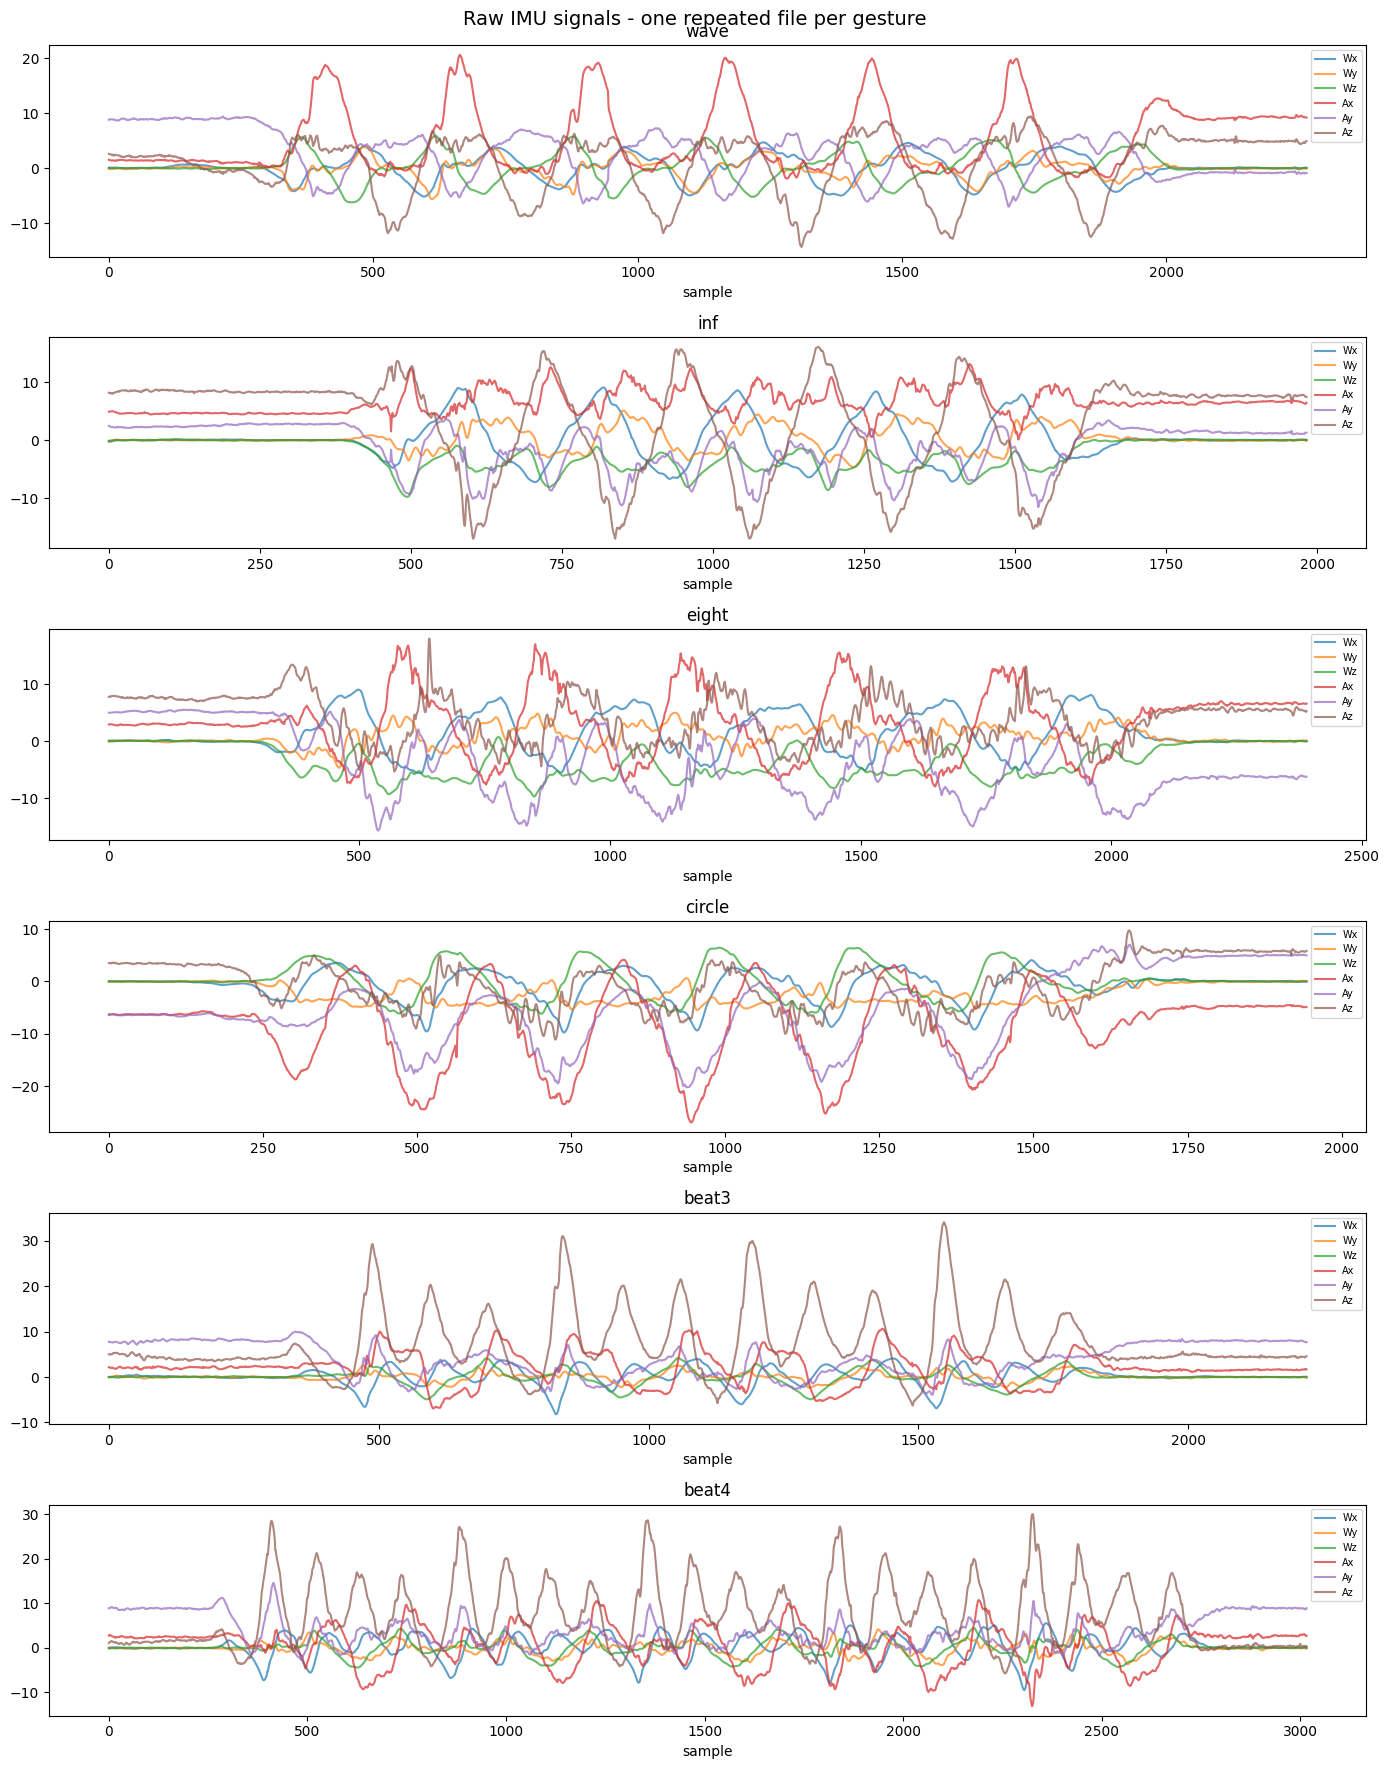

In [3]:
channel_names = ['Wx', 'Wy', 'Wz', 'Ax', 'Ay', 'Az']

fig, axes = plt.subplots(6, 1, figsize=(14, 18))
fig.suptitle('Raw IMU signals - one repeated file per gesture', fontsize=14)

colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown']

for idx, (gname, dlist) in enumerate(repeated_data.items()):
    ax = axes[idx]
    dat = dlist[0]  # just look at the first file
    for ch in range(6):
        ax.plot(dat[:, ch], alpha=0.7, label=channel_names[ch])
    ax.set_title(gname)
    ax.legend(loc='upper right', fontsize=7)
    ax.set_xlabel('sample')

plt.tight_layout()
plt.show()

## Splitting repeated gestures into individual ones

The repeated gesture files contain the same gesture done multiple times. I wanted to split them into individual gestures. So I looked at the signal energy to find the "rest" periods between repetitions.

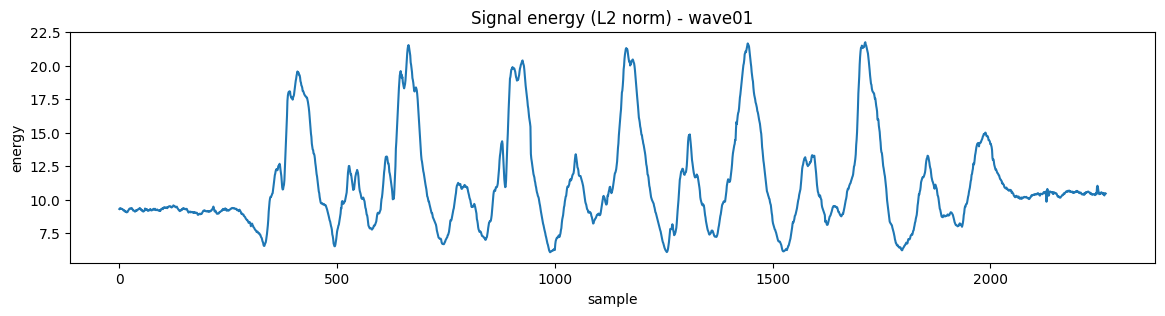

energy stats: min=6.085, max=21.741, mean=11.156


In [4]:
# first let me look at what the energy looks like for a wave file
test_dat = repeated_data['wave'][0]
energy = np.sqrt(np.sum(test_dat**2, axis=1))

plt.figure(figsize=(14, 3))
plt.plot(energy)
plt.title('Signal energy (L2 norm) - wave01')
plt.xlabel('sample')
plt.ylabel('energy')
plt.show()
print("energy stats: min={:.3f}, max={:.3f}, mean={:.3f}".format(energy.min(), energy.max(), energy.mean()))

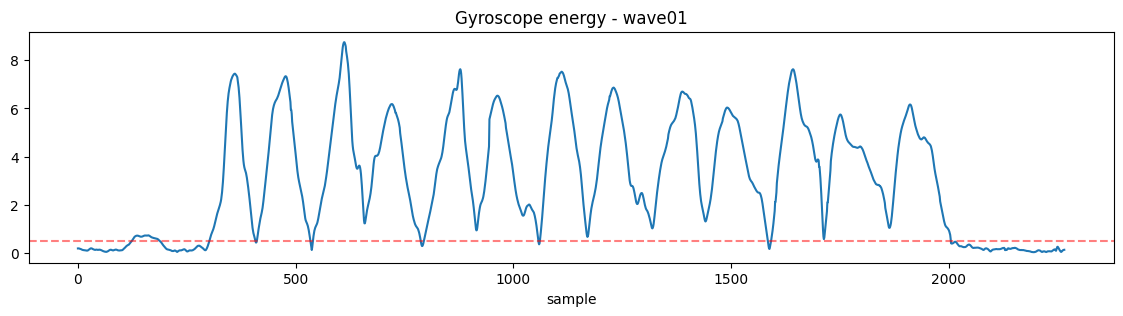

gyro energy stats: 0.023961734390481836 8.754146785229615 3.0421260046705427


In [5]:
# The energy doesn't really go to zero between repetitions
# because of gravity component in accelerometer (always ~9.8)
# Try looking at just the gyroscope channels which should be near zero when not moving

gyro_energy = np.sqrt(np.sum(test_dat[:, :3]**2, axis=1))

plt.figure(figsize=(14, 3))
plt.plot(gyro_energy)
plt.title('Gyroscope energy - wave01')
plt.axhline(y=0.5, color='r', linestyle='--', alpha=0.5)
plt.xlabel('sample')
plt.show()
print("gyro energy stats:", gyro_energy.min(), gyro_energy.max(), gyro_energy.mean())

In [6]:
def segment_gesture(imu_data, threshold=0.3, min_gesture_len=50, min_gap=30):
    """
    split a repeated gesture recording into individual gestures
    using gyroscope energy to find rest periods
    """
    gyro = imu_data[:, :3]
    energy = np.sqrt(np.sum(gyro**2, axis=1))
    
    # smooth it a bit
    kernel_size = 15
    kernel = np.ones(kernel_size) / kernel_size
    smooth_energy = np.convolve(energy, kernel, mode='same')
    
    # find active regions (above threshold)
    active = smooth_energy > threshold
    
    # find transitions
    segments = []
    in_gesture = False
    start = 0
    
    for i in range(len(active)):
        if active[i] and not in_gesture:
            start = i
            in_gesture = True
        elif not active[i] and in_gesture:
            if i - start >= min_gesture_len:
                segments.append((start, i))
            in_gesture = False
    
    # don't forget the last one if it ends while active
    if in_gesture and len(active) - start >= min_gesture_len:
        segments.append((start, len(active)))
    
    # merge segments that are too close together
    merged = []
    for seg in segments:
        if merged and seg[0] - merged[-1][1] < min_gap:
            merged[-1] = (merged[-1][0], seg[1])
        else:
            merged.append(seg)
    
    return [imu_data[s:e] for s, e in merged], merged

# test on wave01
segs, boundaries = segment_gesture(test_dat)
print(f"found {len(segs)} segments")
print("segment lengths:", [len(s) for s in segs])
print("boundaries:", boundaries)

found 2 segments
segment lengths: [83, 1727]
boundaries: [(114, 197), (298, 2025)]


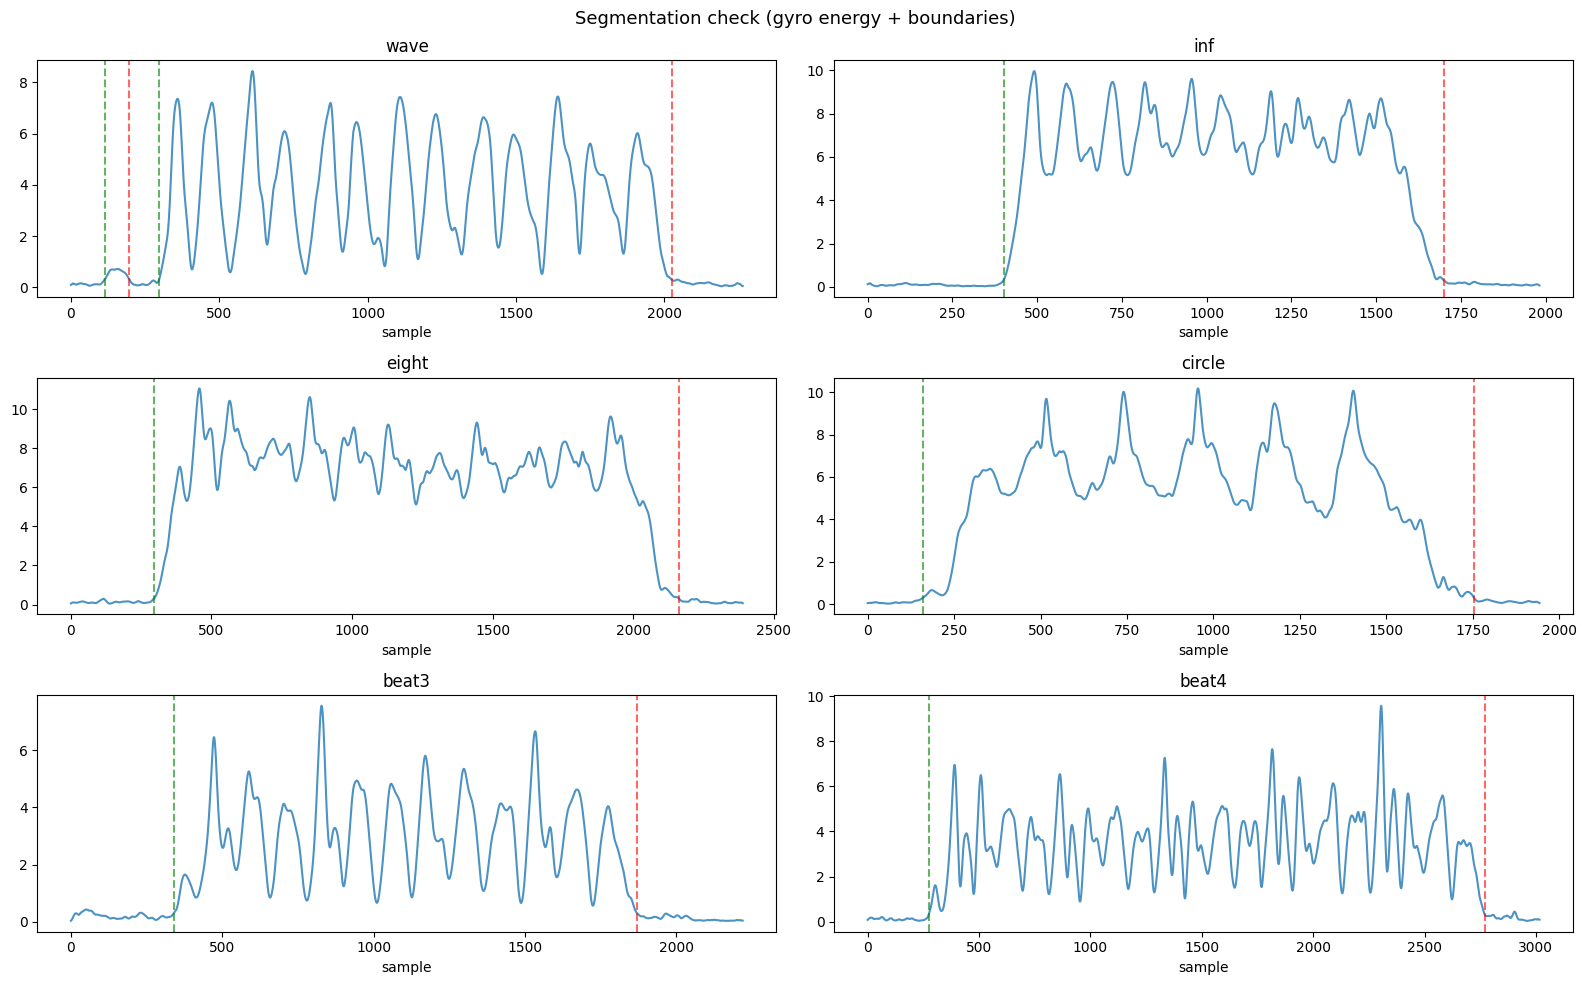

In [7]:
# visualize the segmentation for a few gestures
fig, axes = plt.subplots(3, 2, figsize=(16, 10))
fig.suptitle('Segmentation check (gyro energy + boundaries)', fontsize=13)

for idx, gname in enumerate(gesture_prefixes.keys()):
    ax = axes[idx // 2][idx % 2]
    dat = repeated_data[gname][0]
    gyro_e = np.sqrt(np.sum(dat[:, :3]**2, axis=1))
    
    # smooth for display
    k = np.ones(15) / 15
    smooth = np.convolve(gyro_e, k, mode='same')
    
    ax.plot(smooth, alpha=0.8)
    ax.set_title(gname)
    
    _, bounds = segment_gesture(dat)
    for s, e in bounds:
        ax.axvline(x=s, color='g', linestyle='--', alpha=0.6)
        ax.axvline(x=e, color='r', linestyle='--', alpha=0.6)
    
    ax.set_xlabel('sample')

plt.tight_layout()
plt.show()

Hmm so the segmentation basically gives one big chunk per file...the gestures are done continuously without clear rest periods between reps, the repeated files have maybe 3-6 reps but my method can't split them.

In [8]:

# apply to all files to confirm
for gname in gesture_prefixes.keys():
    total_segs = 0
    for dat in repeated_data[gname]:
        segs, _ = segment_gesture(dat)
        total_segs += len(segs)
    avg_single_len = np.mean([len(s) for s in single_data[gname]])
    print(f"{gname}: {total_segs} segments from 5 files (expected ~{5 * repeated_data[gname][0].shape[0] / avg_single_len:.0f}+ individual gestures)")

wave: 6 segments from 5 files (expected ~26+ individual gestures)
inf: 5 segments from 5 files (expected ~12+ individual gestures)
eight: 6 segments from 5 files (expected ~20+ individual gestures)
circle: 6 segments from 5 files (expected ~15+ individual gestures)
beat3: 5 segments from 5 files (expected ~15+ individual gestures)
beat4: 5 segments from 5 files (expected ~18+ individual gestures)


## Right Plan: No split, use cyclic LR-HMM

Splitting the repeated gestures is not really working - the person just keeps moving without pausing between reps. 
|
The HMM will need a cyclic left-to-right structure (last state can transition back to first state).

So my training data will be:
- Repeated gesture files:each file = 1 long sequence with the ~3-6 times repeated gesture 
- Single gesture files: each file = 1 short sequence with one gesture

In [9]:
# Use each repeated file as one training sequence ， single gesture files go to validation set 
training_raw = {}
val_raw = {}
for gname in gesture_prefixes.keys():
    training_raw[gname] = repeated_data[gname]
    val_raw[gname] = single_data[gname]
    lens = [len(s) for s in training_raw[gname]]
    print(f"{gname}: {len(training_raw[gname])} train sequences, lengths: {lens}")
    print(f"  + {len(val_raw[gname])} validation (single), length: {[len(s) for s in val_raw[gname]]}")

wave: 5 train sequences, lengths: [2266, 2526, 3225, 3070, 3443]
  + 1 validation (single), length: [441]
inf: 5 train sequences, lengths: [1983, 3379, 2495, 2125, 2435]
  + 1 validation (single), length: [852]
eight: 5 train sequences, lengths: [2391, 3148, 3371, 2633, 2758]
  + 1 validation (single), length: [596]
circle: 5 train sequences, lengths: [1944, 2354, 2133, 2295, 1901]
  + 1 validation (single), length: [628]
beat3: 5 train sequences, lengths: [2220, 2608, 2643, 2865, 3095]
  + 1 validation (single), length: [749]
beat4: 5 train sequences, lengths: [3017, 3088, 2307, 2613, 3009]
  + 1 validation (single), length: [845]


## Vector Quantization with K-means

I need to discretize the continuous 6D IMU vectors into discrete observation labels for the HMM. Using k-means clustering.

But first I noticed the raw accel channels have way higher variance than gyro because of the gravity component (~9.8 m/s²). If I run kmeans directly the clusters would be dominated by accelerometer values. So I normalize first: subtract per-sequence mean (removes gravity bias) then divide by global std (equalizes channel contributions).

After that, k-means with M=70. I tried 70 first and it looked fine, later did a small grid search over [65, 70, 75] to confirm.

In [ ]:
# normalize before kmeans: per-sequence mean removal + global std scaling

# Without this accel dominates everything because of gravity

all_centered = []
for gname, seq_list in training_raw.items():
    for seq in seq_list:
        all_centered.append(seq - seq.mean(axis=0))
for gname, seq_list in val_raw.items():
    for seq in seq_list:
        all_centered.append(seq - seq.mean(axis=0))

all_stacked = np.vstack(all_centered)
global_std = all_stacked.std(axis=0)
global_std[global_std < 1e-8] = 1.0  # avoid div by zero

print("per-channel std (after centering):")
for i, ch in enumerate(channel_names):
    print(f"  {ch}: {global_std[i]:.4f}")

all_imu = all_stacked / global_std

# check variance balance
total_var = all_imu.var(axis=0).sum()
gyro_pct = all_imu[:, :3].var(axis=0).sum() / total_var * 100
accel_pct = all_imu[:, 3:].var(axis=0).sum() / total_var * 100
print(f"\nvariance split: gyro {gyro_pct:.1f}% / accel {accel_pct:.1f}%")
print(f"total vectors: {all_imu.shape}")

# normalize all sequences for later quantization
training_norm = {}
for gname, seq_list in training_raw.items():
    training_norm[gname] = [(s - s.mean(axis=0)) / global_std for s in seq_list]

val_norm = {}
for gname, seq_list in val_raw.items():
    val_norm[gname] = [(s - s.mean(axis=0)) / global_std for s in seq_list]

per-channel std (after centering):
  Wx: 3.1036
  Wy: 1.6168
  Wz: 2.4367
  Ax: 4.9737
  Ay: 5.0927
  Az: 6.1542

variance split: gyro 50.0% / accel 50.0%
total vectors: (83451, 6)


fitting kmeans with 70 clusters...
done! inertia: 60665.00682568627
cluster sizes: min=343, max=4515, mean=1192.2
empty clusters: 0


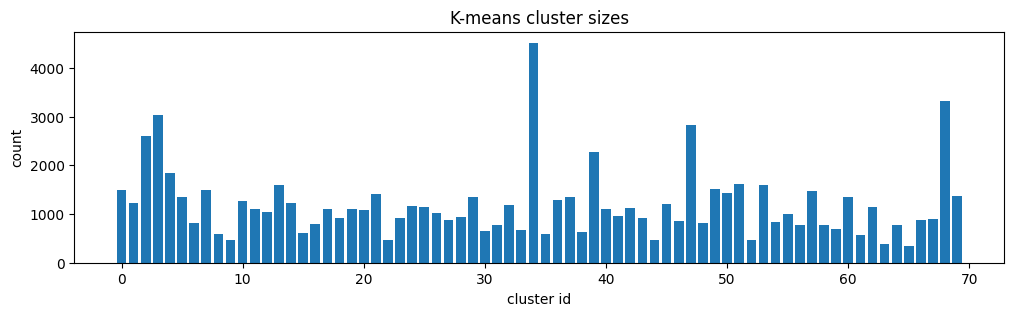

In [11]:
M = 70  # clusters 65, 70, 75
print(f"fitting kmeans with {M} clusters...")
kmeans = KMeans(n_clusters=M, random_state=42, n_init=10, max_iter=300)
kmeans.fit(all_imu)
print("done! inertia:", kmeans.inertia_)

# check empty clusters
labels_all = kmeans.labels_
cluster_sizes = np.bincount(labels_all, minlength=M)
print(f"cluster sizes: min={cluster_sizes.min()}, max={cluster_sizes.max()}, mean={cluster_sizes.mean():.1f}")
print(f"empty clusters: {np.sum(cluster_sizes == 0)}")

plt.figure(figsize=(12, 3))
plt.bar(range(M), cluster_sizes)
plt.title('K-means cluster sizes')
plt.xlabel('cluster id')
plt.ylabel('count')
plt.show()

In [12]:
# quantize all training sequences (using normalized data)
def quantize(seq, km):
    return km.predict(seq)

training_obs = {}
for gname, seq_list in training_norm.items():
    training_obs[gname] = [quantize(s, kmeans) for s in seq_list]
    print(f"{gname}: {len(training_obs[gname])} sequences")
    print(f"  seq lengths: {[len(s) for s in training_obs[gname]]}")

# quantize validation sequences too
print("\nvalidation sequences:")
val_obs = {}
for gname, seq_list in val_norm.items():
    val_obs[gname] = [quantize(s, kmeans) for s in seq_list]
    print(f"  {gname}: length {[len(s) for s in val_obs[gname]]}")

wave: 5 sequences
  seq lengths: [2266, 2526, 3225, 3070, 3443]
inf: 5 sequences
  seq lengths: [1983, 3379, 2495, 2125, 2435]
eight: 5 sequences
  seq lengths: [2391, 3148, 3371, 2633, 2758]
circle: 5 sequences
  seq lengths: [1944, 2354, 2133, 2295, 1901]
beat3: 5 sequences
  seq lengths: [2220, 2608, 2643, 2865, 3095]
beat4: 5 sequences
  seq lengths: [3017, 3088, 2307, 2613, 3009]

validation sequences:
  wave: length [441]
  inf: length [852]
  eight: length [596]
  circle: length [628]
  beat3: length [749]
  beat4: length [845]


In [13]:
import pickle

os.makedirs('models', exist_ok=True)

# save normalization params
with open('models/norm_params.pkl', 'wb') as f:
    pickle.dump({'global_std': global_std}, f)
print("saved normalization params")

# save kmeans model
with open('models/kmeans_model.pkl', 'wb') as f:
    pickle.dump(kmeans, f)
print("saved kmeans model")

# save quantized training data
with open('models/training_obs.pkl', 'wb') as f:
    pickle.dump(training_obs, f)
print("saved training observations")

# also save the raw training sequences in case I need them later
with open('models/training_raw.pkl', 'wb') as f:
    pickle.dump(training_raw, f)
print("saved raw training data")

print(f"\nM = {M} clusters, total {sum(len(v) for v in training_obs.values())} training sequences")

saved normalization params
saved kmeans model
saved training observations
saved raw training data

M = 70 clusters, total 30 training sequences


## HMM Implementation

Time to build the actual HMM. Following Rabiner's paper mostly - the forward/backward algorithms and Baum-Welch for training. I'll use scaling to avoid numerical underflow (section V of the paper).

The plan is:
1. Build an HMM class with forward, backward, and training
2. Test it on some toy data first to make sure it works
3. Then train on the real gesture data

In [14]:
class HMM:
    def __init__(self, n_states, n_obs, topology='left-right-cyclic'):
        self.N = n_states
        self.M = n_obs
        self.topology = topology
        
        if topology == 'ergodic':
            self.pi = np.ones(self.N) / self.N
            self.A = np.random.dirichlet(np.ones(self.N), size=self.N)
        else:
            # left-right cyclic: start in state 0, can go forward or loop back
            self.pi = np.zeros(self.N)
            self.pi[0] = 1.0
            self.A = np.zeros((self.N, self.N))
            for i in range(self.N):
                stay = 0.5 + np.random.uniform(0, 0.2)
                self.A[i, i] = stay
                nxt = (i + 1) % self.N  # cyclic: last state -> first state
                self.A[i, nxt] = 1.0 - stay
        
        # B: random emission probs
        self.B = np.random.dirichlet(np.ones(self.M), size=self.N)
        self.B += 1e-8
        self.B /= self.B.sum(axis=1, keepdims=True)
        
        # mask for A structure - enforce during training
        self.A_mask = (self.A > 0).astype(float)
    
    def forward(self, obs):
        # scaled forward (rabiner section V)
        T = len(obs)
        alpha = np.zeros((self.N, T))
        c = np.zeros(T)
        
        alpha[:, 0] = self.pi * self.B[:, obs[0]]
        c[0] = alpha[:, 0].sum() + 1e-300
        alpha[:, 0] /= c[0]
        
        for t in range(1, T):
            alpha[:, t] = (self.A.T @ alpha[:, t-1]) * self.B[:, obs[t]]
            c[t] = alpha[:, t].sum() + 1e-300
            alpha[:, t] /= c[t]
        return alpha, c
    
    def backward(self, obs, c):
        T = len(obs)
        beta = np.zeros((self.N, T))
        beta[:, T-1] = 1.0 / c[T-1]
        for t in range(T-2, -1, -1):
            beta[:, t] = self.A @ (self.B[:, obs[t+1]] * beta[:, t+1])
            beta[:, t] /= c[t]
        return beta
    
    def log_likelihood(self, obs):
        _, c = self.forward(obs)
        return np.sum(np.log(c))
    
    def train(self, obs_sequences, max_iter=100, tol=1e-4, verbose=True):
        ll_history = []
        
        for epoch in range(max_iter):
            total_ll = 0
            # accumulate stats directly instead of storing all gamma/xi
            # (the old way kept all xi arrays in memory and blew up on long runs)
            xi_sum = np.zeros((self.N, self.N))
            gamma_denom_A = np.zeros(self.N)
            gamma_denom_B = np.zeros(self.N)
            B_numer = np.zeros((self.N, self.M))
            
            for obs in obs_sequences:
                alpha, c = self.forward(obs)
                beta = self.backward(obs, c)
                T = len(obs)
                
                gamma = alpha * beta
                gamma /= gamma.sum(axis=0, keepdims=True) + 1e-300
                
                # accumulate stats for B
                gamma_denom_B += gamma.sum(axis=1)
                for t in range(T):
                    B_numer[:, obs[t]] += gamma[:, t]
                
                # accumulate stats for A
                gamma_denom_A += gamma[:, :-1].sum(axis=1)
                for t in range(T-1):
                    bj_beta = self.B[:, obs[t+1]] * beta[:, t+1]
                    xi_t = alpha[:, t:t+1] * self.A * bj_beta[np.newaxis, :]
                    xi_t /= xi_t.sum() + 1e-300
                    xi_sum += xi_t
                
                total_ll += np.sum(np.log(c))
            
            ll_history.append(total_ll)
            
            if epoch > 0:
                ll_change = total_ll - ll_history[-2]
                if verbose and epoch % 5 == 0:
                    print(f"  epoch {epoch}: LL = {total_ll:.2f} (change: {ll_change:.4f})")
                if ll_change < -0.01:
                    print(f"  WARNING: LL decreased at epoch {epoch}!")
                if abs(ll_change) < tol:
                    if verbose:
                        print(f"  converged at epoch {epoch}, LL = {total_ll:.2f}")
                    break
            elif verbose:
                print(f"  epoch 0: LL = {total_ll:.2f}")
            
            # M-step: update A
            gamma_denom_A[gamma_denom_A == 0] = 1e-300
            A_new = xi_sum / gamma_denom_A[:, np.newaxis]
            A_new *= self.A_mask  # enforce structure
            A_new /= A_new.sum(axis=1, keepdims=True) + 1e-300
            
            # M-step: update B
            gamma_denom_B[gamma_denom_B == 0] = 1e-300
            B_new = B_numer / gamma_denom_B[:, np.newaxis]
            B_new += 1e-8
            B_new /= B_new.sum(axis=1, keepdims=True)
            
            self.A = A_new
            self.B = B_new
        
        if verbose:
            print(f"  done: LL = {ll_history[-1]:.2f}, {len(ll_history)} epochs")
        return ll_history

print("HMM class ready")

HMM class ready


## Testing on toy data

I created a 2-state, 2-observation toy problem:
- State 0 always emits observation 0
- State 1 emits 0 or 1 with equal probability
- The sequence goes: 1000 zeros, then 1000 random {0,1}, then 1000 zeros

In [15]:
# generate toy data
np.random.seed(123)
seg1 = np.zeros(1000, dtype=int)           # state 0: always emits 0
seg2 = np.random.randint(0, 2, size=1000)  # state 1: emits 0 or 1 equally
seg3 = np.zeros(1000, dtype=int)           # state 0 again
toy_obs = np.concatenate([seg1, seg2, seg3])
print("toy obs:", toy_obs.shape, "unique:", np.unique(toy_obs))

# train on this
np.random.seed(4)  # tried a few seeds, this one converges nicely
toy_hmm = HMM(n_states=2, n_obs=2, topology='ergodic')
print("training...")
toy_ll = toy_hmm.train([toy_obs], max_iter=100, tol=1e-6)

toy obs: (3000,) unique: [0 1]
training...
  epoch 0: LL = -1396.16
  epoch 5: LL = -1362.74 (change: 5.0589)
  epoch 10: LL = -1249.90 (change: 51.0180)
  epoch 15: LL = -708.82 (change: 32.0050)
  converged at epoch 18, LL = -707.50
  done: LL = -707.50, 19 epochs


Learned A:
[[9.98996563e-01 1.00343720e-03]
 [5.02374098e-04 9.99497626e-01]]

Learned B:
[[4.80438924e-01 5.19561076e-01]
 [9.99999990e-01 1.04039591e-08]]

state 1 -> zeros emitter: B = [9.99999990e-01 1.04039591e-08] (expect ~[1, 0])
state 0 -> mixed emitter:  B = [0.48043892 0.51956108] (expect ~[0.5, 0.5])
A diag: [0.9995, 0.9990] (expect ~0.999)

LL monotonic: True


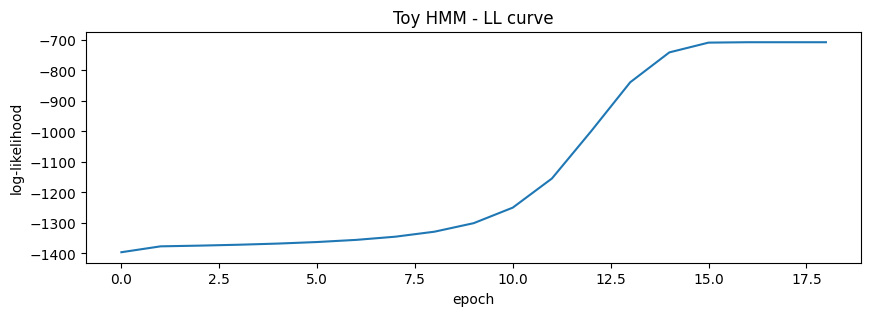

In [16]:
# check results
print("Learned A:")
print(toy_hmm.A)
print("\nLearned B:")
print(toy_hmm.B)

# figure out which state is which (labels can be swapped)
if toy_hmm.B[0, 1] < toy_hmm.B[1, 1]:
    s0, s1 = 0, 1
else:
    s0, s1 = 1, 0
print(f"\nstate {s0} -> zeros emitter: B = {toy_hmm.B[s0]} (expect ~[1, 0])")
print(f"state {s1} -> mixed emitter:  B = {toy_hmm.B[s1]} (expect ~[0.5, 0.5])")
print(f"A diag: [{toy_hmm.A[s0,s0]:.4f}, {toy_hmm.A[s1,s1]:.4f}] (expect ~0.999)")

# LL
ll_diffs = np.diff(toy_ll)
print(f"\nLL monotonic: {np.all(ll_diffs >= -1e-6)}")

plt.figure(figsize=(10, 3))
plt.plot(toy_ll)
plt.title('Toy HMM - LL curve')
plt.xlabel('epoch'); plt.ylabel('log-likelihood')
plt.show()

## Training gesture HMMs

In [ ]:
N = 15  # hidden states, manually searched in [10, 15, 20]
gesture_models = {}
gesture_ll_curves = {}

for gname in gesture_prefixes.keys():
    print(f"\n=== Training {gname} ===")
    np.random.seed(42)
    hmm = HMM(n_states=N, n_obs=M, topology='left-right-cyclic')
    ll = hmm.train(training_obs[gname], max_iter=200, tol=1e-2)
    gesture_models[gname] = hmm
    gesture_ll_curves[gname] = ll
    print(f"  A diag range: [{np.diag(hmm.A).min():.3f}, {np.diag(hmm.A).max():.3f}]")


=== Training wave ===
  epoch 0: LL = -55512.24
  epoch 5: LL = -11318.99 (change: 1098.7862)
  epoch 10: LL = -11137.19 (change: 21.0672)
  epoch 15: LL = -11027.28 (change: 16.7477)
  epoch 20: LL = -11016.43 (change: 0.5062)
  epoch 25: LL = -11011.85 (change: 1.8698)
  epoch 30: LL = -10970.00 (change: 9.6793)
  epoch 35: LL = -10958.71 (change: 0.9310)
  epoch 40: LL = -10951.57 (change: 1.9413)
  epoch 45: LL = -10925.11 (change: 8.8605)
  epoch 50: LL = -10906.89 (change: 0.3172)
  epoch 55: LL = -10906.63 (change: 0.0292)
  epoch 60: LL = -10906.35 (change: 0.0946)
  epoch 65: LL = -10903.43 (change: 1.3822)
  epoch 70: LL = -10873.70 (change: 7.6927)
  epoch 75: LL = -10782.91 (change: 72.6229)
  epoch 80: LL = -9764.37 (change: 2.8139)
  epoch 85: LL = -9753.06 (change: 2.6104)
  epoch 90: LL = -9737.94 (change: 0.9569)
  epoch 95: LL = -9723.87 (change: 0.7811)
  epoch 100: LL = -9719.61 (change: 0.6896)
  epoch 105: LL = -9717.83 (change: 0.1565)
  epoch 110: LL = -9716.87

In [ ]:
 # plot LL curves for all gestures
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Training LL curves (all gestures)', fontsize=14)

for idx, gname in enumerate(gesture_prefixes.keys()):
    ax = axes[idx // 3][idx % 3]
    ax.plot(gesture_ll_curves[gname])
    ax.set_title(gname)
    ax.set_xlabel('epoch')
    ax.set_ylabel('LL')
    # check monotonicity
    diffs = np.diff(gesture_ll_curves[gname])
    is_mono = np.all(diffs >= -0.1)
    ax.set_title(f"{gname} ({'ok' if is_mono else 'BAD'})")

plt.tight_layout()
plt.savefig('docs/figures/ll_curves_all.png', dpi=100)
plt.show()
print("saved LL curves to docs/figures/")

In [ ]:
# Leave-One-Out Cross-Validation for each gesture
print("=== Leave-One-Out Cross-Validation ===\n")

loocv_results = []  # (true_gesture, fold, pred, top3, correct)
correct = 0
total = 0

for true_gesture in gesture_prefixes.keys():
    seqs = training_obs[true_gesture]
    n_seqs = len(seqs)
    gcorrect = 0
    
    for fold in range(n_seqs):
        train_seqs = [seqs[i] for i in range(n_seqs) if i != fold]
        val_seq = seqs[fold]
        
        # retrain this gesture's model without the held-out seq
        np.random.seed(42)
        fold_hmm = HMM(n_states=N, n_obs=M, topology='left-right-cyclic')
        fold_hmm.train(train_seqs, max_iter=200, tol=1e-2, verbose=False)
        
        # classify against all models
        lls = {}
        for gname in gesture_prefixes.keys():
            if gname == true_gesture:
                lls[gname] = fold_hmm.log_likelihood(val_seq)
            else:
                lls[gname] = gesture_models[gname].log_likelihood(val_seq)
        
        ranked = sorted(lls.items(), key=lambda x: -x[1])
        pred = ranked[0][0]
        top3 = [r[0] for r in ranked[:3]]
        is_correct = pred == true_gesture
        correct += int(is_correct)
        gcorrect += int(is_correct)
        
        total += 1
        
        seq_type = "single" if fold == n_seqs - 1 else f"rep{fold+1}"
        mark = "ok" if is_correct else "WRONG"
        print(f"  {true_gesture} [{seq_type}]: pred={pred} [{mark}]  top3={top3}")
        loocv_results.append((true_gesture, fold, pred, top3, is_correct))
    
    print(f"  -> {true_gesture}: {gcorrect}/{n_seqs}\n")

t3_corr = sum(1 for tg, _, _, t3, _ in loocv_results if tg in t3)
print(f"Overall LOOCV: {correct}/{total} = {correct/total:.1%} Top-1, {t3_corr}/{total} = {t3_corr/total:.1%} Top-3")

In [ ]:
# confusion matrix from LOOCV
gnames = list(gesture_prefixes.keys())
n_gestures = len(gnames)
conf = np.zeros((n_gestures, n_gestures), dtype=int)

for true_g, fold, pred_g, _, _ in loocv_results:
    i = gnames.index(true_g)
    j = gnames.index(pred_g)
    conf[i, j] += 1

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(conf, cmap='Blues')
ax.set_xticks(range(n_gestures))
ax.set_yticks(range(n_gestures))
ax.set_xticklabels(gnames, rotation=45)
ax.set_yticklabels(gnames)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title(f'LOOCV Confusion Matrix ({correct}/{total} = {correct/total:.1%})')

# put numbers in cells
for i in range(n_gestures):
    for j in range(n_gestures):
        color = 'white' if conf[i, j] > 3 else 'black'
        ax.text(j, i, str(conf[i, j]), ha='center', va='center', color=color, fontsize=14)

plt.colorbar(im)
plt.tight_layout()
plt.savefig('docs/figures/loocv_confusion.png', dpi=100)
plt.show()
print("saved confusion matrix")

In [ ]:
# retrain on everything (repeated + single) for the final saved models
print("=== Retraining final models on all data (repeated + single) ===\n")
final_models = {}
final_ll_curves = {}

for gname in gesture_prefixes.keys():
    all_seqs = training_obs[gname] + val_obs[gname]
    print(f"\n--- {gname} ({len(all_seqs)} sequences) ---")
    np.random.seed(42)
    hmm = HMM(n_states=N, n_obs=M, topology='left-right-cyclic')
    ll = hmm.train(all_seqs, max_iter=200, tol=1e-2)
    final_models[gname] = hmm
    final_ll_curves[gname] = ll

print("\ndone retraining all models")

: 

In [ ]:
# save the final retrained models
for gname, model in final_models.items():
    model_data = {
        'A': model.A, 'B': model.B, 'pi': model.pi,
        'N': model.N, 'M': model.M,
        'topology': model.topology
    }
    fname = f'models/{gname}_hmm.pkl'
    with open(fname, 'wb') as f:
        pickle.dump(model_data, f)
    print(f"saved {fname}")

print("all models saved")

: 